In [89]:
from pandas import read_csv
import numpy as np
from matplotlib import pyplot as plt

In [90]:
import configparser

# Initialize the parser
config = configparser.ConfigParser()

# Read the config file
config.read('config.ini')

ACCELERATION_SMOOTHING = config['processing'].getfloat('acceleration_smoothing')

In [91]:
def load_mtn(path):
    df = read_csv(path)
    df = df[df['pressure'] != 0]
    df[['acc_x', 'acc_y', 'acc_z']] = df[['acc_x', 'acc_y', 'acc_z']] * 9.81
    df['acc'] = np.sqrt(df['acc_x'] ** 2 + df['acc_y'] ** 2 + df['acc_z'] ** 2)

    return df

We will only work with the df['acc'] column as this will allow us to change it to just acc_z in the future if need be

In [92]:
def initial_pressure_corrections(df):
    df['pressure'] = df['pressure'] - df['pressure'].iloc[0]


In [93]:
def smooth_acc(df):
    
    def adjust_acc(row, prev=[None]):
        if prev[0] is None:
            prev[0] = row
            return row
        
        curr = (prev[0] + ACCELERATION_SMOOTHING * row) / (1 + ACCELERATION_SMOOTHING)
        prev[0] = row
        return curr
    
    df['acc'] = df['acc'].apply(adjust_acc)

In [94]:
def get_velocity(df):
    df['velocity'] = 0.0

    for i in range(1, len(df)):
        dt = df['timestamps'].iloc[i] - df['timestamps'].iloc[i - 1]
        avg_acc = (df['acc'].iloc[i] + df['acc'].iloc[i - 1]) / 2
        
        df.at[i, 'velocity'] = df['velocity'].iloc[i - 1] + avg_acc * dt

In [95]:
def get_distance(df):
    df['distance'] = 0.0

    for i in range(1, len(df)):
        dt = df['timestamps'].iloc[i] - df['timestamps'].iloc[i - 1]
        avg_vel = (df['velocity'].iloc[i] + df['velocity'].iloc[i - 1]) / 2

        df.at[i, 'distance'] = df['distance'].iloc[i - 1] + avg_vel * dt

In [96]:
df = load_mtn("./mtn/sensor_data (1).mtn")
initial_pressure_corrections(df)
smooth_acc(df)
get_velocity(df)
get_distance(df)


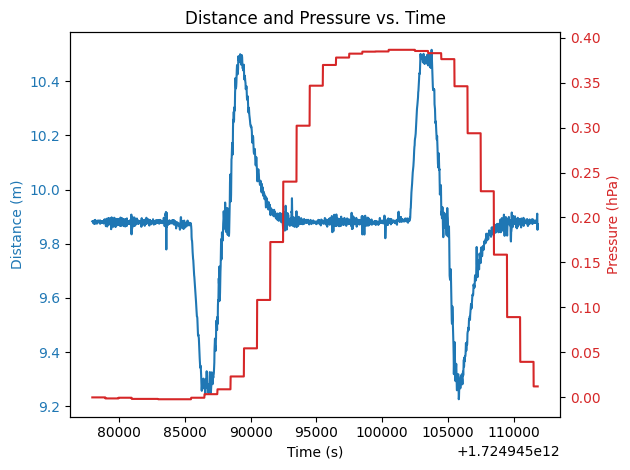

In [97]:
fig, ax1 = plt.subplots()

# Plot distance on the primary y-axis
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Distance (m)', color='tab:blue')
ax1.plot(df['timestamps'], df['velocity'], color='tab:blue', label='Distance')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a secondary y-axis for pressure
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.set_ylabel('Pressure (hPa)', color='tab:red')  # we already handled the x-label with ax1
ax2.plot(df['timestamps'], df['pressure'], color='tab:red', label='Pressure')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Add a title and show the plot
plt.title('Distance and Pressure vs. Time')
fig.tight_layout()  # adjust the layout to make room for labels
plt.show()